In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 32

In [ ]:
train_datagen = ImageDataGenerator(rescale=1./255,validation_split=0.2)

In [ ]:
train_generator = train_datagen.flow_from_directory(

'/content/drive/MyDrive/Rajesh /Braintumor/Brain_Tumor_Detection',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)


Found 2400 images belonging to 2 classes.


In [ ]:
val_generator = train_datagen.flow_from_directory(

'/content/drive/MyDrive/Rajesh /Braintumor/Brain_Tumor_Detection',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
       subset='validation'
)



Found 600 images belonging to 2 classes.


In [ ]:
model = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu',
input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam', loss='binary_crossentropy',
metrics=['accuracy'])

In [ ]:
model.fit(train_generator, epochs=5, validation_data=val_generator,
batch_size= BATCH_SIZE)

Epoch 1/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 790s 10s/step - accuracy: 0.7954 - loss: 0.4919 - val_accuracy: 0.8350 - val_loss: 0.3579
Epoch 2/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 11s 140ms/step - accuracy: 0.9271 - loss: 0.1972 - val_accuracy: 0.9667 - val_loss: 0.0994
Epoch 3/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 11s 142ms/step - accuracy: 0.9750 - loss: 0.0856 - val_accuracy: 0.9883 - val_loss: 0.0418
Epoch 4/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 11s 147ms/step - accuracy: 0.9817 - loss: 0.0502 - val_accuracy: 0.9950 - val_loss: 0.0304
Epoch 5/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 11s 146ms/step - accuracy: 0.9933 - loss: 0.0239 - val_accuracy: 0.9917 - val_loss: 0.0246


In [ ]:
model.save('/content/drive/MyDrive/Brain_Tumor_Detection/brain_tumor.h5')

In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt #visualisation
import numpy as np
model = load_model('/content/drive/MyDrive/Brain_Tumor_Detection/brain_tumor.h5')
print("Model Loaded")


Model Loaded


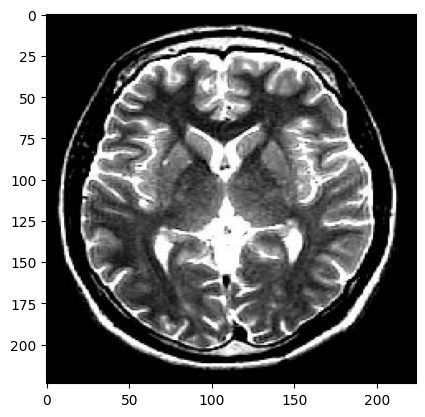

In [ ]:
test_image_path="/content/drive/MyDrive/Rajesh /Braintumor/Brain_Tumor_Detection/no/No14.jpg"
img=image.load_img(test_image_path,target_size=(224,224))
plt.imshow(img)
plt.axis()
plt.show()

In [ ]:
img_array=image.img_to_array(img)
img_array=np.expand_dims(img_array,axis=0)
img_array /= 255.

In [ ]:
prediction = model.predict(img_array)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


In [ ]:
print(prediction)

[[1.2824535e-06]]


In [ ]:
if prediction >= 0.5:
    print("You have brain tumor.")
else:print("You do not have brain tumor.")

You do not have brain tumor.
